# Compute Stress Fields
<br>

**Author:** Jack Logan

This notebook generates the strain rate and stress tensors from the derived velocities. The file `blue_ice_tools.py` contains many helper functions for calculating the Cauchy stress tensor from velocity fields and some helper functions for plotting.

The code in this notebook generates Figures 1 and 3. 

### Import Packages

In [1]:
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd

import blue_ice_tools as bit

import cmocean.cm as ccm     # Colormaps
import matplotlib.cm as mcm  # Colormaps
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# . . Matplotlib font parameters
plt.rcParams.update({
    "mathtext.fontset": "dejavuserif",
    "font.family": "serif",
    "font.size":14,
})

## Load Data

Here we load the shapefiles for the figures, the velocity dataset, and the cropped fracture dataset.

The velocity and fracture data will be available in Zenodo.

The Landsat-8 imagery can be loaded in from EarthExplorer or the AWS cloud access example found [here](https://book.cryointhecloud.com/is2-cloud-landsat-integration/).

In [2]:
# . . Read shapefiles
shirase_shape = gpd.read_file('../data/shapefiles/shirase.shp')
grounding_line = gpd.read_file('../data/shapefiles/RINGS_grounded_2022_polyline.shp')
coastline = gpd.read_file('../data/shapefiles/add_coastline_medium_res_line_v7_10.shp')

# . . Get velocity data for shirase, calculate stresses
vel = xr.open_dataset('../data/velocity/velocity-timeseries.nc', decode_coords='all')
vel = vel.sel(mid_date='2022-12-13', method='nearest')

# . . Load in fracture data, merge w/ stress
frac = xr.open_dataset('../data/shirase-fracture.nc', decode_coords='all')
frac = frac.sel(mid_date='2022-12-13', method='bfill')

# . . Landsat RGB image for background
img_da = xr.open_dataarray('../data/landsat-rgb.nc')
img = img_da.transpose("y", "x", "band").values

## Figure 1: Study Area

Use the Landsat 8 RGB image to generate a study area map of the Shirase Glacier blue ice zone (BIZ).
Plot the Quantarctica coastline and catchment area, and the RINGS 2022 grounding line, with labels for geographic areas, and a small inset map showing global context.

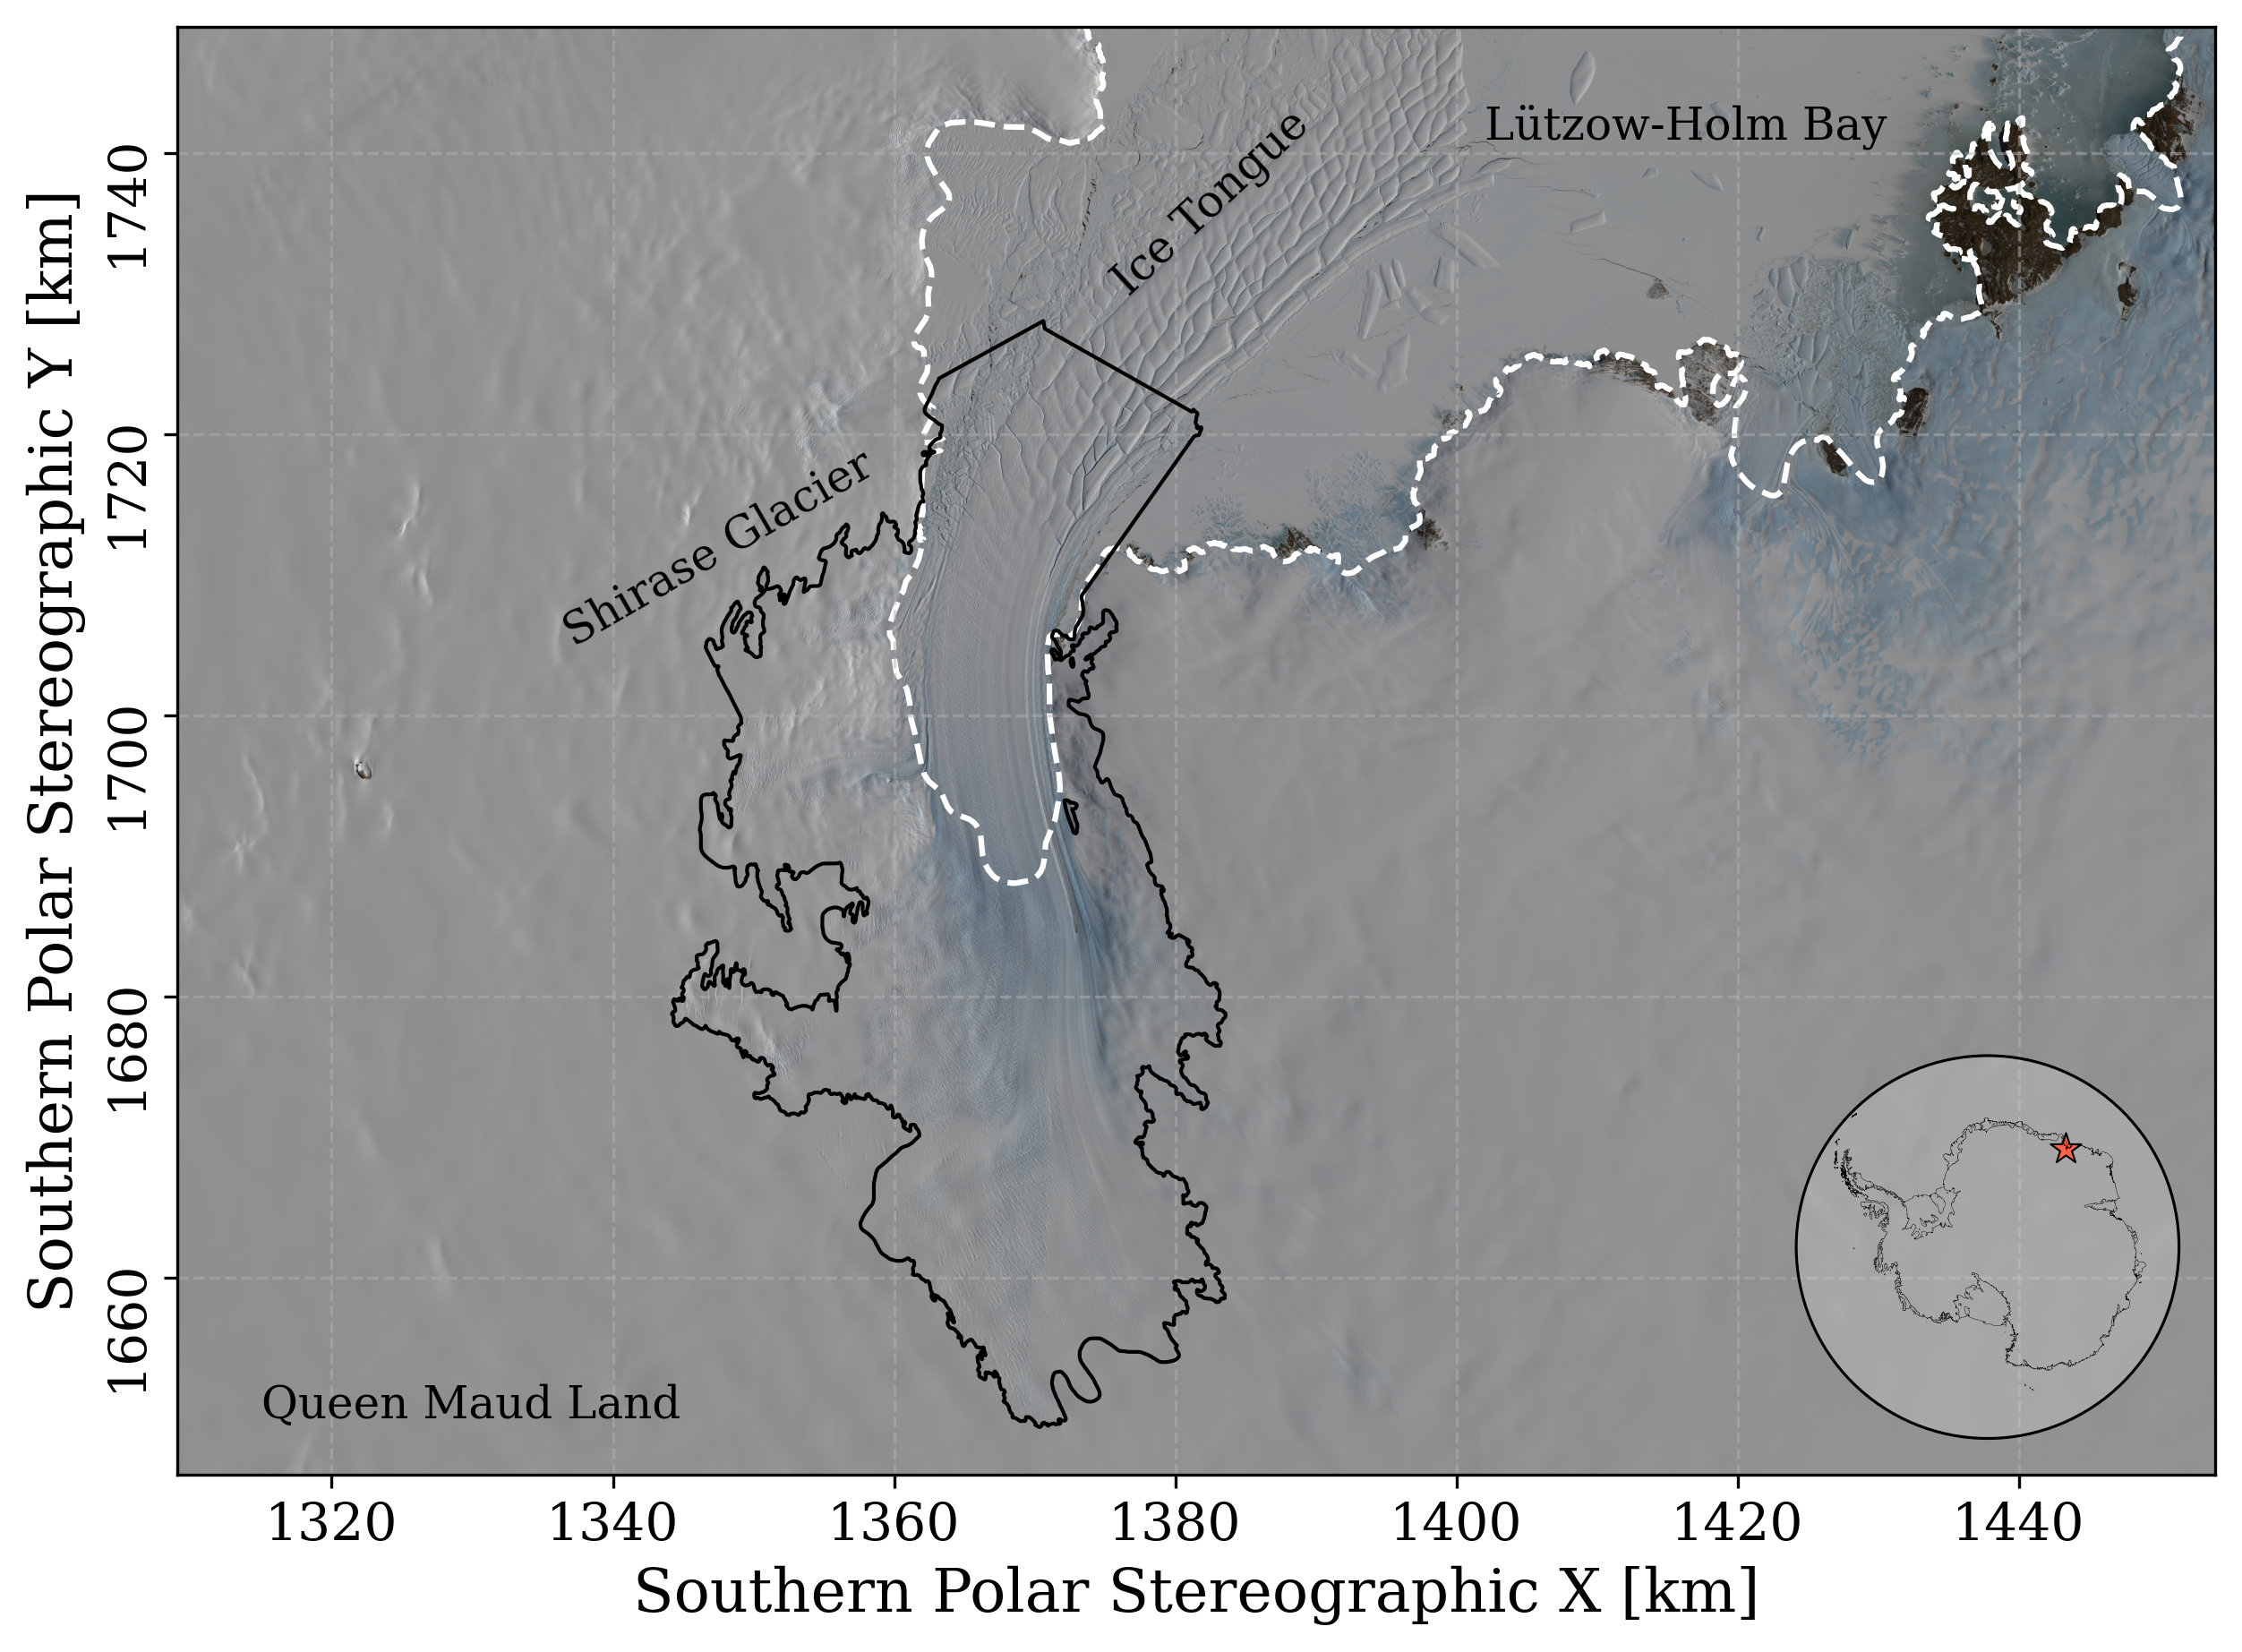

In [3]:
fig, ax = plt.subplots(figsize=(10,7), dpi=300)

# Show Landsat-8 image as RGB
x0, x1 = float(img_da.x.min()), float(img_da.x.max())
y0, y1 = float(img_da.y.min()), float(img_da.y.max())
extent = [x0, x1, y0, y1]  # [xmin, xmax, ymin, ymax]
ax.imshow(img, extent=extent, origin='lower', zorder=0)

fs = 12

# . . Plot shapefile outlines
shirase_shape.plot(ax=ax, fc='none', ec='k', zorder=2)
grounding_line.plot(ax=ax, fc='none', ec='w', ls='--', zorder=1)

# . . Annotate prominent labels
# ax.annotate('Shirase   Glacier', (1.362e6, 1.68e6), fontsize=fs, rotation=85)
ax.annotate('Shirase Glacier', (1.336e6, 1.705e6), fontsize=fs, rotation=30)
ax.annotate('Ice Tongue', (1.375e6, 1.730e6), fontsize=fs, rotation=43)
ax.annotate('Queen Maud Land', (1.315e6, 1.65e6), fontsize=fs)
ax.annotate('Lützow-Holm Bay', (1.402e6, 1.741e6), fontsize=fs)

# . . Map formatting
ax.set_xlim([x0, x1])
ax.set_ylim([y0, y1])
bit.format_map(ax, fs=16)

# . . Create an inset map for context
iax = inset_axes(ax, loc="lower right", height=1.5, width=1.5, borderpad=.5)

# Plot antactic coastline
coastline.plot(ax=iax, lw=0.1, ec='k', fc='none')

# Set axis limits to a certain radius
r = 3500000
iax.set_xlim([-r, r])
iax.set_ylim([-r, r])

# Indicate location of zoomed region
iax.scatter(1.36e6, 1.71e6, s=75, marker='*', c='tomato', ec='k', lw=0.5)

# Translucent circle for background
iax.add_patch(
    Circle(
        (0.5, 0.5), 0.475,
        transform=iax.transAxes,
        fc='w', alpha=0.2,
        lw=1, zorder=0
    )
)

# Black border for edge of inset
iax.add_patch(
    Circle(
        (0.5, 0.5), 0.475,
        transform=iax.transAxes,
        fc='none', ec='k', 
        lw=.75, zorder=0
    )
)

# Turn axis off (illusion of a circular inset)
iax.set_axis_off()

fig.savefig('../media/f01-study-area.png', bbox_inches='tight')
plt.show()

## Strain Rate & Stress Computation

`bit.calc_strain_stress` derives the full stress state of the ice shelf from a 2D
velocity field (`vx`, `vy`). The function has four stages: gradient estimation, strain rate tensor, rotation, stress tensor.

---

### 1. Gradient Estimation

Spatial velocity gradients are computed across the grid to build the velocity gradient tensor. Three methods are available via `deriv_type`:

| Parameter | Options | Description |
|---|---|---|
| `deriv_type` | `'sav_gol'` (default) | Savitzky-Golay filter — smooths and differentiates simultaneously. Most robust to the noise typical in satellite-derived velocities. |
| | `'stencil'` | Eighth-order finite difference stencil — higher accuracy with less smoothing, more sensitive to noise. |
| | `'deriv'` | xarray's built-in differentiator — fastest, but most noise-sensitive. |
| `window_length` | int, default `11` | *(sav_gol only)* Number of pixels in the sliding window. Larger values mean more smoothing. `25` is used here (~1250 m) to suppress noise where velocities are slow and gradients are small. |
| `polyorder` | int, default `2` | *(sav_gol only)* Polynomial order fit within each window. Lower order = more smoothing; higher order = better edge preservation. |
| `dx`, `dy` | int, default `50` | Grid spacing in metres, used to scale the derivative to physical units. Should match the resolution of the input velocity field. |

---

### 2. Strain Rate Tensor

The four velocity gradients are combined into the symmetric strain rate tensor described in the methods section. This step is automatic.

---

### 3. Tensor Rotation

| Parameter | Options | Description |
|---|---|---|
| `rotate` | `True` (default) | Rotates the strain rate tensor into the local flow coordinate system using the flow direction at each pixel. After rotation, `eps_xx` is along-flow (longitudinal extension/compression) and `eps_yy` is across-flow (lateral spreading). Makes the outputs physically interpretable. |
| | `False` | Keeps the tensor in the original x/y grid coordinate system. |

---

### 4. Stress Tensor

Deviatoric and Cauchy stresses are computed from the strain rates via Glen's Flow Law.
Outputs include the principal stress components (`sigma1`, `sigma2`) and Von Mises stress (`von_mises`), all in Pa by default.

| Parameter | Default | Description |
|---|---|---|
| `n` | `3` | Glen's flow law exponent. `3` is the standard value for ice and is rarely changed. |
| `A` | `3.5e-25` | Temperature-dependent rate factor (Pa$^{-3}$ s$^{-1}$). The default is appropriate for cold Antarctic ice near −20$^\circ$ C. Warmer or more temperate ice would require a higher value. |

---

### Parameters Used Here

```python
stress = bit.calc_strain_stress(vel, window_length=25, dx=50, dy=50)
```

All parameters not specified are left at their defaults: `deriv_type='sav_gol'`,
`polyorder=2`, `rotate=True`, `n=3`, `A=3.5e-25`. The only intentional departures are
`window_length=25` (widened from the default of `11` to smooth the noisy blue ice zone
velocities) and `dx=dy=50` to match the 50 m velocity grid spacing.

In [4]:
# . . Compute strain rates and stresses from velocity snapshot
stress = bit.calc_strain_stress(vel, window_length=25, dx=50, dy=50)

# . . Merge stress and fracture datasets
ds = xr.merge(
    [stress, frac.drop_vars('mid_date')],  # Drop mid_date val from fracture, it's not needed
    compat='no_conflicts'
)

# . . Clip to Shirase geometry
ds = ds.rio.clip(shirase_shape.geometry, shirase_shape.crs)

## Figure 3

Plot a smaller RGB background map with surface fields from 14 December, 2022.
The plot will have six panels, with one panel for fracture confidence, velocity magnitude, effective strain rate, von Mises stress, and Cauchy stress tensor prinicpal components 1 and 2.

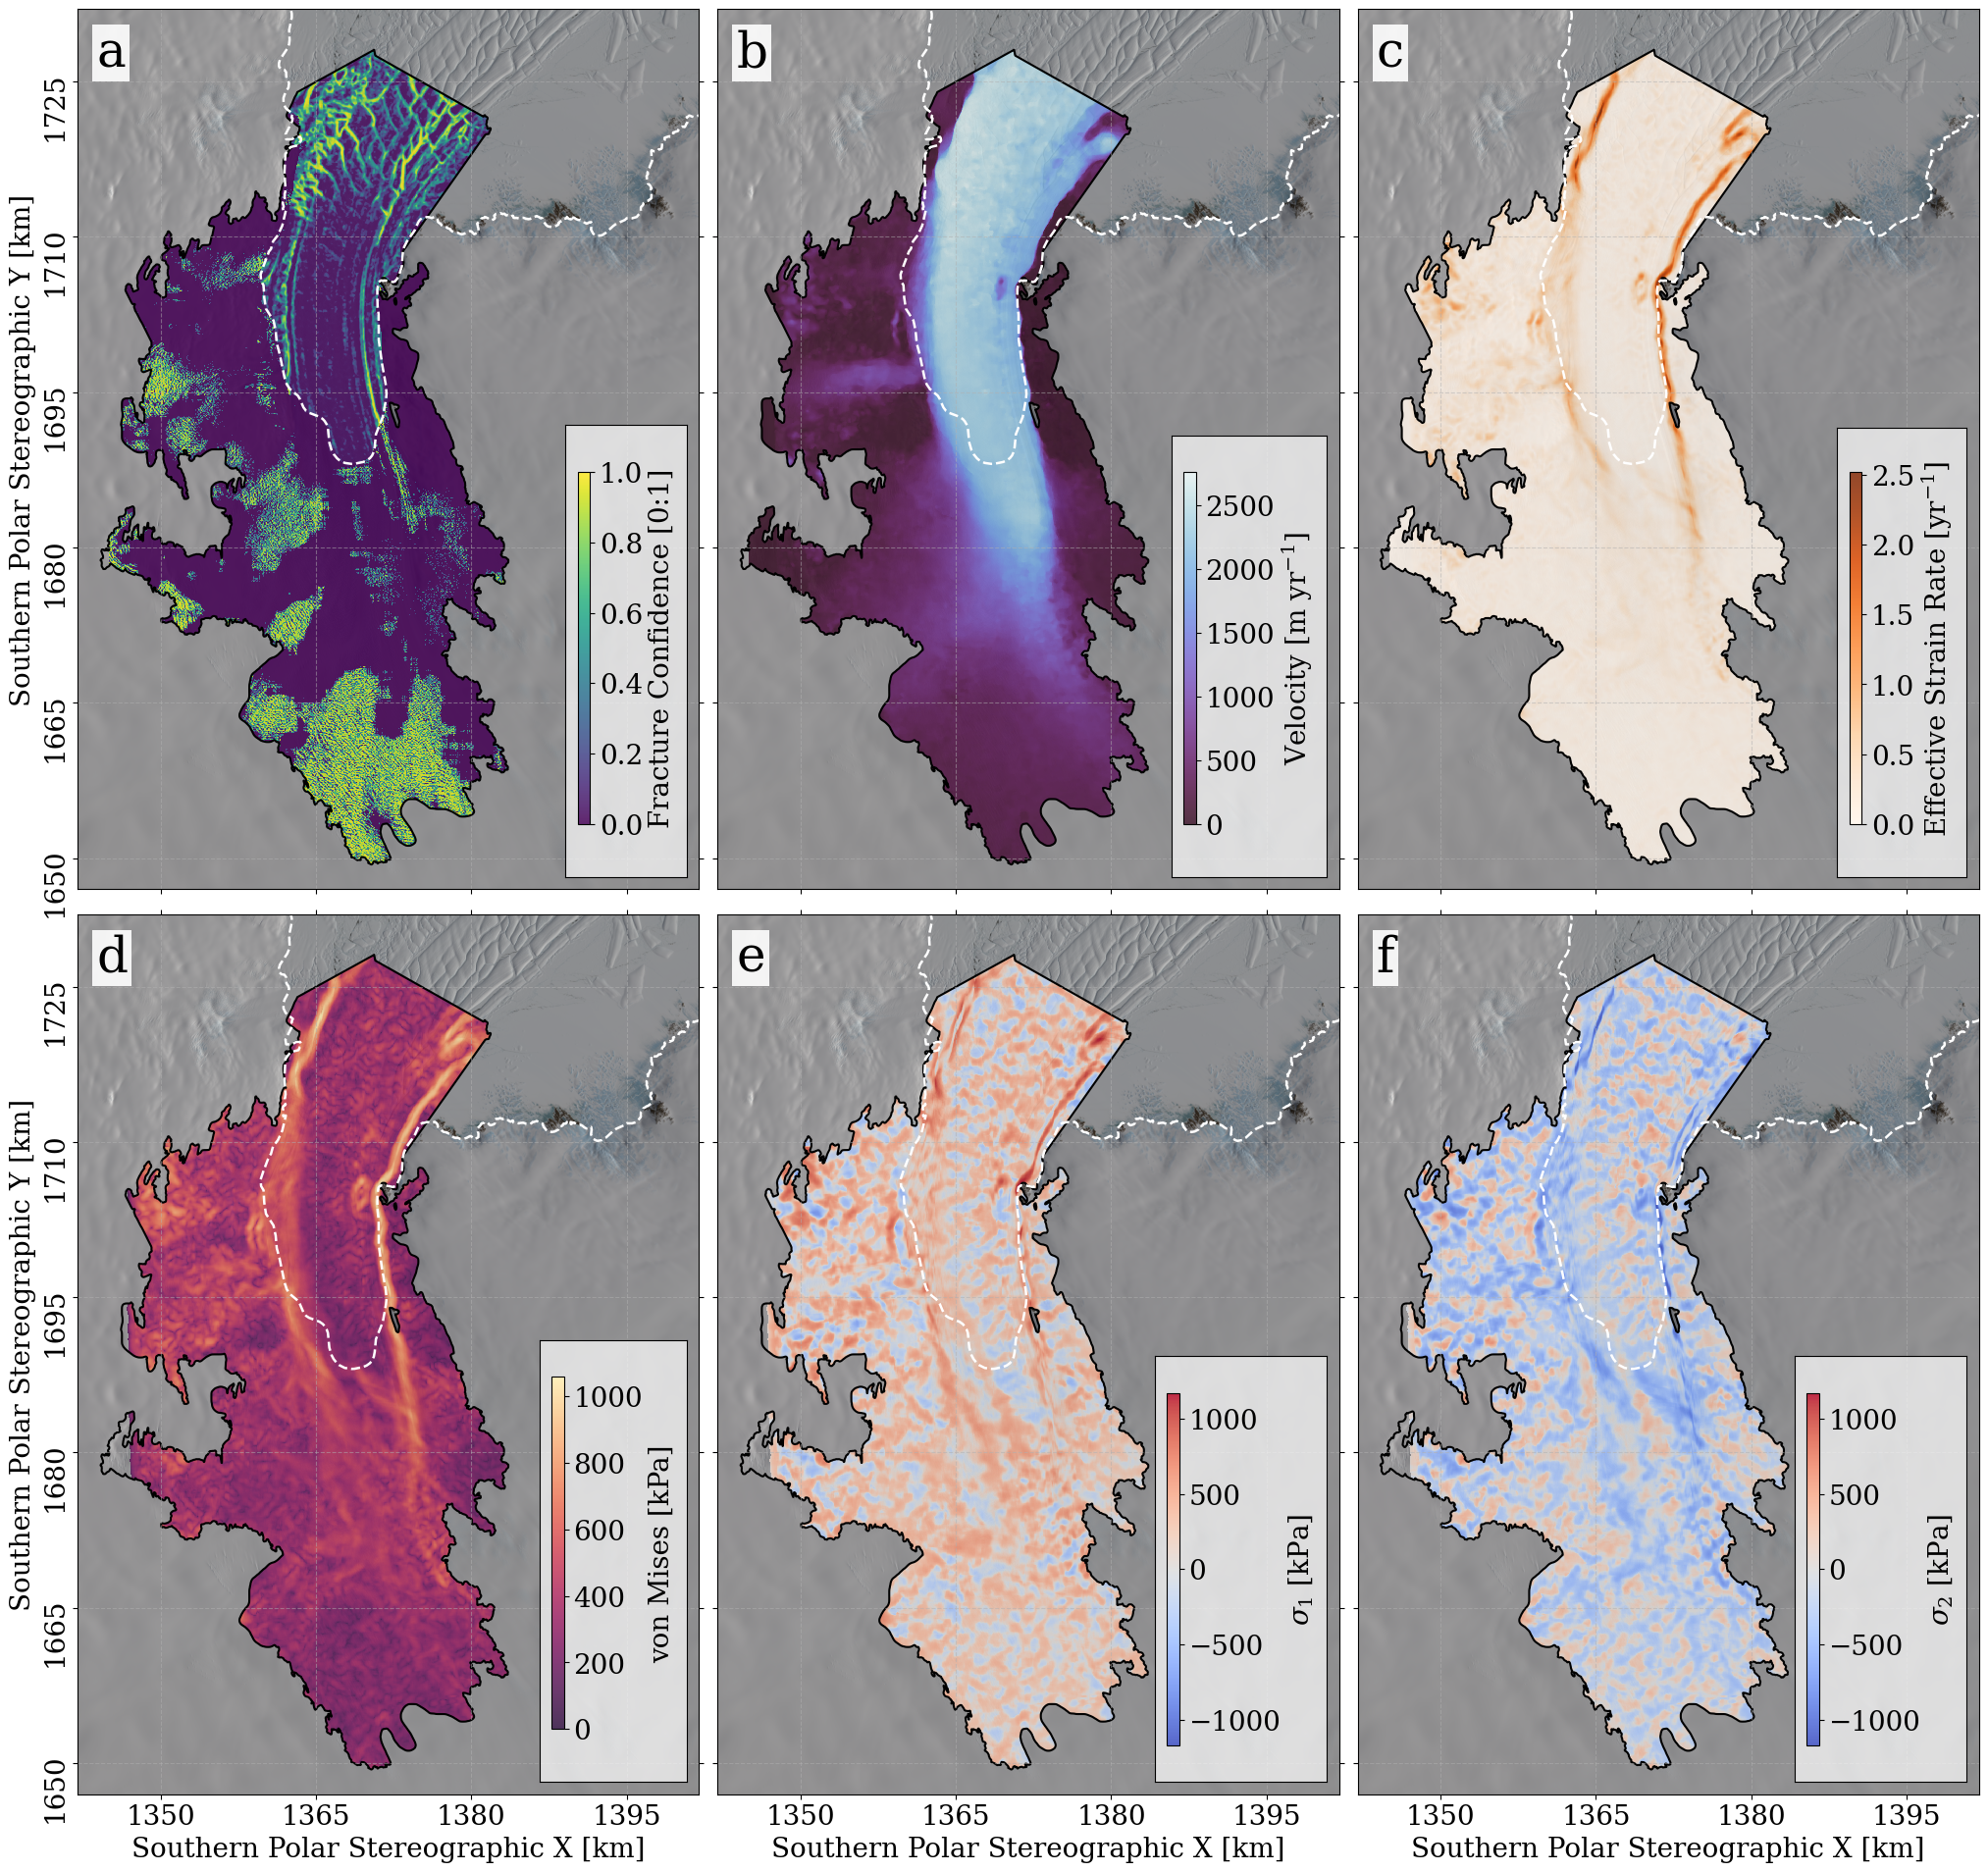

In [5]:
plt.rcParams.update({"font.size":20})

fig, axs = plt.subplots(2, 3, figsize=(25, 25))
axs = axs.flatten()

# . . Map parameters
alpha = .85
qms = [None]*6

# . . Fracture confidence plot
cm_frac = mcm.viridis
qms[0] = ds['fracture_conf'].plot(
    ax=axs[0], cmap=cm_frac, alpha=alpha,
    add_colorbar=False,
    vmin=0, vmax=1
)

# . . Velocity magnitude plot
cm_vel = ccm.dense_r
qms[1] = ds['vv'].plot(
    ax=axs[1], cmap=cm_vel, alpha=alpha,
    add_colorbar=False, 
    vmin=0
)

# . . Effective strain rate
cm_eff = mcm.Oranges
qms[2] = ds['effective'].plot(
    ax=axs[2], cmap=cm_eff, alpha=alpha,
    vmin=0,
    add_colorbar=False,
)

# . . von Mises stress
cm_vm = ccm.matter_r
qms[3] = ds['von_mises'].plot(
    ax=axs[3], cmap=cm_vm, alpha=alpha,
    add_colorbar=False, vmin=0
)

# . . Principal stress 1 plot
cm_sigmas = mcm.coolwarm
amax = np.max([np.abs(ds['sigma1']).max(), np.abs(ds['sigma2']).max()])
# . . Principal stress 1 plot
qms[4] = ds['sigma1'].plot(
    ax=axs[4], cmap=cm_sigmas, alpha=alpha,
    vmin=-amax, vmax=amax,
    add_colorbar=False,
)

# . . Principal stress 2 plot
qms[5] = ds['sigma2'].plot(
    ax=axs[5], cmap=cm_sigmas, alpha=alpha,
    vmin=-amax, vmax=amax,
    add_colorbar=False,
)

# . . Plot formatting for all axes
x0, x1 = float(img_da.x.min()), float(img_da.x.max())
y0, y1 = float(img_da.y.min()), float(img_da.y.max())
extent = [x0, x1, y0, y1]  # [xmin, xmax, ymin, ymax]
for ax in axs:
    # . . Plot Shapefiles and RGB
    shirase_shape.plot(ax=ax, fc='none', ec='#000000', lw=1.5)
    grounding_line.plot(ax=ax, fc='none', ec='#FFFFFF', lw=1.8, ls='--')
    ax.imshow(img, extent=extent, origin='lower', zorder=0)

    ax.set_xlim([1.342e6, 1.402e6])
    ax.set_ylim([1.647e6, 1.732e6])

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=7))
    ax.yaxis.set_ticks_position('both')
    bit.format_map(ax, fs=20)

# . . Hide duplicate axis labels and ticks
for ax in axs[[1, 2, 4, 5]]:
    ax.set_ylabel(None)
    ax.set_yticklabels([])

for ax in axs[[2, 5]]:
    ax.tick_params(
        right=False
    )

for ax in axs[0:3]:
    ax.set_xlabel(None)
    ax.set_xticklabels([])

for ax in axs[3:]:
    ax.tick_params(
        top=True, bottom=True,
        labelbottom=True, labeltop=False
    )

# . . Adjust figure
plt.subplots_adjust(wspace=0.03, hspace=-0.08)

# . . Add colorbar as insets to each axis
labels = [
    'Fracture Confidence [0:1]', 'Velocity [m yr$^{-1}$]', 'Effective Strain Rate [yr$^{-1}$]',
    'von Mises [kPa]', '$\\sigma_1$ [kPa]', '$\\sigma_2$ [kPa]'    
]
tags = list('abcdef')
cbars = []
for i, ax in enumerate(axs):
    cbars.append(bit.inset_colorbar(fig, ax, qms[i], labels[i], inset=0.005))
    bit.map_patch(ax, tags[i])

plt.savefig('../media/f03-landsat-six-panel.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()